In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.pipeline import make_pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.model_selection import GridSearchCV
from yellowbrick.classifier import PrecisionRecallCurve
from yellowbrick.classifier import ROCAUC
from sklearn.svm import SVC

In [ ]:
data = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/um/data_rfe_selected (1).csv')
data

,lead_time,arrival_date_year,arrival_date_week_number,stays_in_weekend_nights,stays_in_week_nights,adults,children,meal,is_repeated_guest,previous_cancellations,...,customer_type_Transient-Party,country_BRA,country_DEU,country_ESP,country_IRL,country_ITA,country_NLD,country_Other,country_PRT,is_canceled
0,342,2015,27,0,0,2,0.0,1,0,0,...,False,False,False,False,False,False,False,False,True,0
1,737,2015,27,0,0,2,0.0,1,0,0,...,False,False,False,False,False,False,False,False,True,0
2,7,2015,27,0,1,1,0.0,1,0,0,...,False,False,False,False,False,False,False,False,False,0
3,13,2015,27,0,1,1,0.0,1,0,0,...,False,False,False,False,False,False,False,False,False,0
4,14,2015,27,0,2,2,0.0,1,0,0,...,False,False,False,False,False,False,False,False,False,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119384,23,2017,35,2,5,2,0.0,1,0,0,...,False,False,False,False,False,False,False,False,False,0
119385,102,2017,35,2,5,3,0.0,1,0,0,...,False,False,False,False,False,False,False,False,False,0
119386,34,2017,35,2,5,2,0.0,1,0,0,...,False,False,True,False,False,False,False,False,False,0
119387,109,2017,35,2,5,2,0.0,1,0,0,...,False,False,False,False,False,False,False,False,False,0


In [ ]:
X = data.drop(columns=['is_canceled'])
y = data['is_canceled']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

scaler = MinMaxScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Logistic Regression

In [ ]:
lr = LogisticRegression(solver='saga', C=100, penalty='l1', max_iter = 5000)
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)
print(accuracy_score(y_test,y_pred))

0.8122399977664237


In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.81      0.91      0.86     22446
           1       0.81      0.65      0.72     13371

    accuracy                           0.81     35817
   macro avg       0.81      0.78      0.79     35817
weighted avg       0.81      0.81      0.81     35817



In [ ]:
confusion_matrix(y_test, y_pred)

array([[20416,  2030],
       [ 4695,  8676]])

In [ ]:
X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(X, y, test_size=0.30, random_state=42)
pipeline_lr = make_pipeline(
    MinMaxScaler(),
    LogisticRegression(solver='saga', max_iter=1000)
)
param_grid_lr = {
    'logisticregression__penalty': ['l1', 'l2'],
    'logisticregression__C': [0.001, 0.01, 0.1, 1, 10, 100]
}
grid_lr = GridSearchCV(pipeline_lr, param_grid_lr, cv=5, scoring = 'f1', n_jobs=-1)
grid_lr.fit(X_train_raw, y_train_raw)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('minmaxscaler', MinMaxScaler()),
                                       ('logisticregression',
                                        LogisticRegression(max_iter=1000,
                                                           solver='saga'))]),
             n_jobs=-1,
             param_grid={'logisticregression__C': [0.001, 0.01, 0.1, 1, 10,
                                                   100],
                         'logisticregression__penalty': ['l1', 'l2']},
             scoring='f1')

In [ ]:
print("Najlepsze parametry LR:", grid_lr.best_params_)

Najlepsze parametry LR: {'logisticregression__C': 100, 'logisticregression__penalty': 'l2'}


In [ ]:
lr = LogisticRegression(solver='saga', max_iter=1000, C=100, penalty ='l2')
lr.fit(X_train, y_train)

LogisticRegression(C=100, max_iter=1000, solver='saga')

In [ ]:
y_pred = lr.predict(X_test)

In [ ]:
print(accuracy_score(y_test,y_pred))

0.8121562386576207


In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.81      0.91      0.86     22446
           1       0.81      0.65      0.72     13371

    accuracy                           0.81     35817
   macro avg       0.81      0.78      0.79     35817
weighted avg       0.81      0.81      0.81     35817



## k-NN

In [ ]:
X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(X, y, test_size=0.30, random_state=42)
pipeline_knn = make_pipeline(
    MinMaxScaler(),
    KNeighborsClassifier()
)

param_grid_knn = {
    'kneighborsclassifier__n_neighbors': [5, 7, 9, 11],
    'kneighborsclassifier__weights': ['uniform', 'distance'],
    'kneighborsclassifier__metric': ['euclidean', 'manhattan']
}

grid_knn = GridSearchCV(pipeline_knn, param_grid_knn, cv=5, scoring='f1', n_jobs=-1)
grid_knn.fit(X_train_raw, y_train_raw)

print("Najlepsze parametry KNN:", grid_knn.best_params_)

Najlepsze parametry KNN: {'kneighborsclassifier__metric': 'manhattan', 'kneighborsclassifier__n_neighbors': 11, 'kneighborsclassifier__weights': 'distance'}


In [ ]:
klasyfikator = KNeighborsClassifier(n_neighbors=11,weights='distance', metric = 'manhattan')
klasyfikator.fit(X_train,y_train)
y_pred= klasyfikator.predict(X_test)

In [ ]:
print(accuracy_score(y_test,y_pred))

0.8573303180054164


In [ ]:
cm = confusion_matrix(y_test, y_pred)
cm

array([[20074,  2372],
       [ 2738, 10633]])

In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.88      0.89      0.89     22446
           1       0.82      0.80      0.81     13371

    accuracy                           0.86     35817
   macro avg       0.85      0.84      0.85     35817
weighted avg       0.86      0.86      0.86     35817



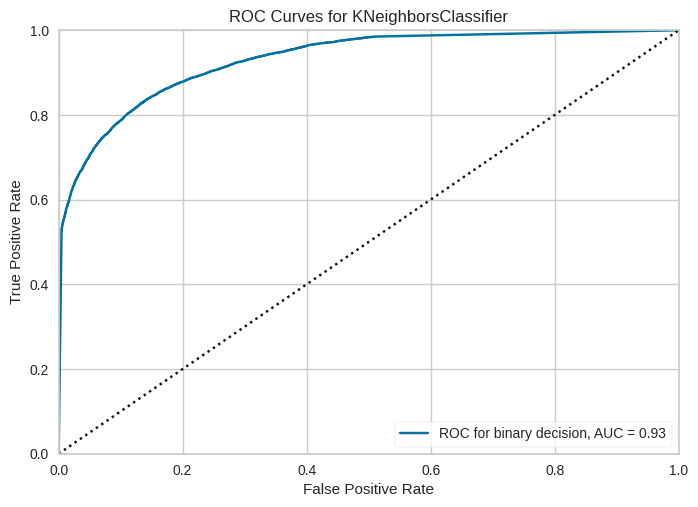

<Axes: title={'center': 'ROC Curves for KNeighborsClassifier'}, xlabel='False Positive Rate', ylabel='True Positive Rate'>

In [ ]:
from yellowbrick.classifier import ROCAUC
vis = ROCAUC(klasyfikator, binary=True)

vis.fit(X_train, y_train)
vis.score(X_test, y_test)
vis.show()

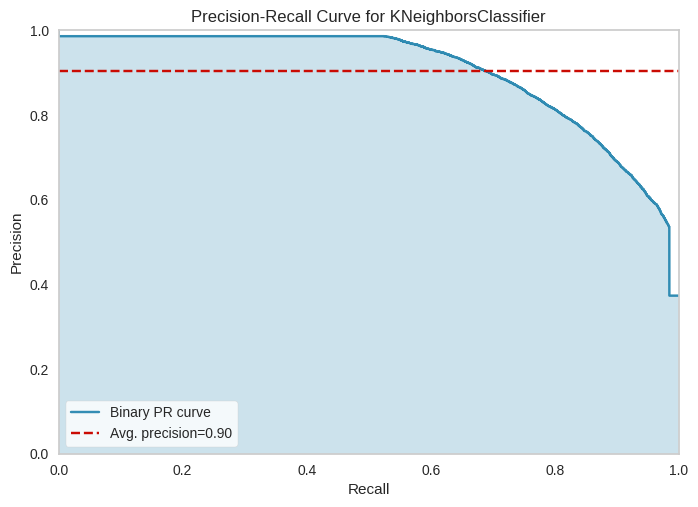

<Axes: title={'center': 'Precision-Recall Curve for KNeighborsClassifier'}, xlabel='Recall', ylabel='Precision'>

In [ ]:
from yellowbrick.classifier import PrecisionRecallCurve
viz = PrecisionRecallCurve(klasyfikator)
viz.fit(X_train, y_train)
viz.score(X_test, y_test)
viz.show()

## SVM

In [ ]:
svm = SVC(kernel="rbf", C=10)
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)
accuracy_score(y_test, y_pred_svm)

0.8541753915738337

In [ ]:
print(classification_report(y_test, y_pred_svm))

              precision    recall  f1-score   support

           0       0.86      0.91      0.89     22446
           1       0.84      0.75      0.79     13371

    accuracy                           0.85     35817
   macro avg       0.85      0.83      0.84     35817
weighted avg       0.85      0.85      0.85     35817



In [ ]:
confusion_matrix(y_test, y_pred)

array([[20416,  2030],
       [ 4695,  8676]])

In [ ]:
X_sample, _, y_sample, _ = train_test_split(X_train, y_train, train_size=20000, stratify=y_train, random_state=42)

pipeline_svc = make_pipeline(
    MinMaxScaler(),
    SVC()
)

param_grid_svc = [
    {'svc__kernel': ['rbf'], 'svc__C': [0.1, 1, 10]},
    {'svc__kernel': ['poly'], 'svc__C': [0.1, 1, 10], 'svc__degree': [2, 3]}
]

grid_svc = GridSearchCV(pipeline_svc, param_grid_svc, cv=3, n_jobs=-1)
grid_svc.fit(X_sample, y_sample)

print("Najlepsze parametry SVC:", grid_svc.best_params_)

Najlepsze parametry SVC: {'svc__C': 10, 'svc__degree': 3, 'svc__kernel': 'poly'}


In [ ]:
from sklearn.svm import SVC
svm = SVC(kernel="poly", degree=3, C=10)
svm.fit(X_train, y_train)

SVC(C=10, kernel='poly')

In [ ]:
y_pred_svm = svm.predict(X_test)
accuracy_score(y_test, y_pred_svm)

0.8566602451349917

In [ ]:
confusion_matrix(y_test, y_pred_svm)

array([[20567,  1879],
       [ 3255, 10116]])

In [ ]:
print(classification_report(y_test, y_pred_svm))

              precision    recall  f1-score   support

           0       0.86      0.92      0.89     22446
           1       0.84      0.76      0.80     13371

    accuracy                           0.86     35817
   macro avg       0.85      0.84      0.84     35817
weighted avg       0.86      0.86      0.85     35817



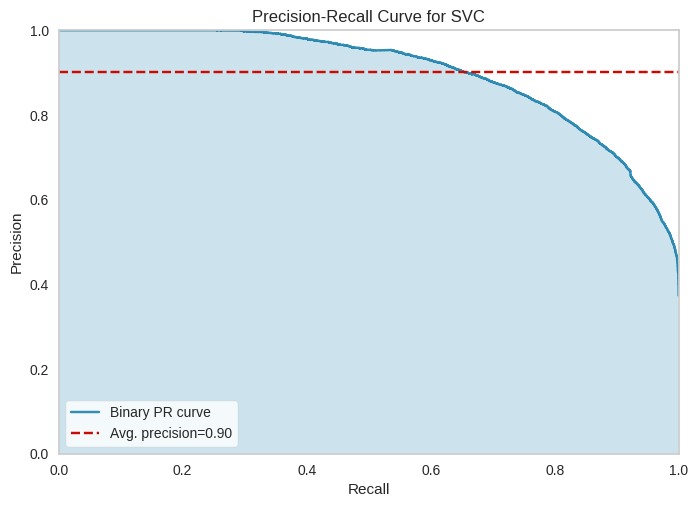

<Axes: title={'center': 'Precision-Recall Curve for SVC'}, xlabel='Recall', ylabel='Precision'>

In [ ]:
viz = PrecisionRecallCurve(svm)
viz.fit(X_train, y_train)
viz.score(X_test, y_test)
viz.show()

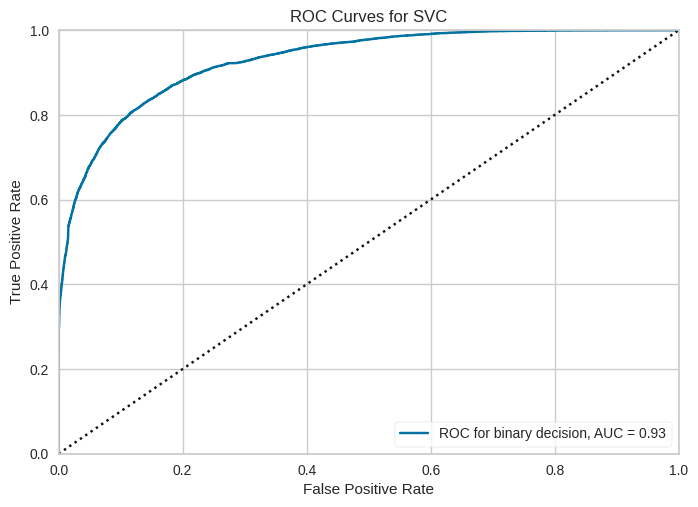

<Axes: title={'center': 'ROC Curves for SVC'}, xlabel='False Positive Rate', ylabel='True Positive Rate'>

In [ ]:
vis = ROCAUC(svm, binary=True)
vis.fit(X_train, y_train)
vis.score(X_test, y_test)
vis.show()

## SMOTE

In [ ]:
from imblearn.over_sampling import SMOTE

In [ ]:
smote = SMOTE(sampling_strategy='minority', random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

In [ ]:
model = KNeighborsClassifier(n_neighbors=11,weights='distance', metric = 'manhattan')
model.fit(X_train_sm, y_train_sm)
y_pred_sm = model.predict(X_test)
print(accuracy_score(y_test, y_pred_sm))

0.8390429125834101


In [ ]:
print(classification_report(y_test, y_pred_sm))

              precision    recall  f1-score   support

           0       0.90      0.83      0.87     22446
           1       0.75      0.85      0.80     13371

    accuracy                           0.84     35817
   macro avg       0.83      0.84      0.83     35817
weighted avg       0.85      0.84      0.84     35817



In [ ]:
cm = confusion_matrix(y_test, y_pred_sm)
cm

array([[18709,  3737],
       [ 2028, 11343]])

In [ ]:
svm = SVC(kernel="poly", degree=3, C=10)
svm.fit(X_train_sm, y_train_sm)
y_pred_svm = svm.predict(X_test)
accuracy_score(y_test, y_pred_svm)

0.8470279476226373

In [ ]:
confusion_matrix(y_test, y_pred_svm)

array([[19032,  3414],
       [ 2065, 11306]])

In [ ]:
print(classification_report(y_test, y_pred_svm))

              precision    recall  f1-score   support

           0       0.90      0.85      0.87     22446
           1       0.77      0.85      0.80     13371

    accuracy                           0.85     35817
   macro avg       0.84      0.85      0.84     35817
weighted avg       0.85      0.85      0.85     35817



## Decision Tree

In [ ]:
from sklearn.tree import DecisionTreeClassifier

In [ ]:
param_grid_tree = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 3, 4],
    'max_features': [None, 'sqrt', 'log2'],
    'class_weight': [None, 'balanced']
}

grid_tree = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid_tree, cv=5, scoring='f1', n_jobs=-1)
grid_tree.fit(X_train_raw, y_train_raw)

print("Najlepsze parametry dla drzewa decyzyjnego:", grid_tree.best_params_)

Najlepsze parametry dla drzewa decyzyjnego: {'class_weight': 'balanced', 'criterion': 'entropy', 'max_depth': 20, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 2}


In [ ]:
tree = DecisionTreeClassifier(random_state=42, class_weight='balanced', criterion= 'entropy', max_depth= 20, max_features= None, min_samples_leaf = 1, min_samples_split=2 )
tree.fit(X_train_raw, y_train_raw)
y_pred_tree = tree.predict(X_test_raw)
accuracy_score(y_test_raw, y_pred_tree)

0.8475584219783902

In [ ]:
print(classification_report(y_test_raw, y_pred_tree))

              precision    recall  f1-score   support

           0       0.90      0.85      0.87     22446
           1       0.77      0.84      0.81     13371

    accuracy                           0.85     35817
   macro avg       0.84      0.85      0.84     35817
weighted avg       0.85      0.85      0.85     35817



In [ ]:
cm = confusion_matrix(y_test_raw, y_pred_tree)
cm

array([[19070,  3376],
       [ 2084, 11287]])